In [72]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [73]:
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_and = torch.tensor([[0.],[0.],[0.],[1.]])
y_or = torch.tensor([[0.],[1.],[1.],[1.]])
y_xor = torch.tensor([[0.],[1.],[1.],[0.]])
loss_fn = nn.BCELoss()

In [74]:
model_and = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

In [75]:
model_or = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

In [76]:
model_xor = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

In [92]:
opt = optim.SGD(model_and.parameters(), lr=0.1)

for _ in range(100):
    opt.zero_grad()
    loss = loss_fn(model_and(X), y_and)
    loss.backward()
    opt.step()

print("AND:", (model_and(X) > 0.5).int().view(-1).tolist())

AND: [0, 0, 0, 1]


In [97]:
opt = optim.SGD(model_or.parameters(), lr=0.1)

for _ in range(200):
    opt.zero_grad()
    loss = loss_fn(model_or(X), y_or)
    loss.backward()
    opt.step()

print("OR :", (model_or(X) > 0.5).int().view(-1).tolist())


OR : [0, 1, 1, 1]


In [98]:
opt = optim.Adam(model_xor.parameters(), lr=0.05)

for _ in range(100):
    opt.zero_grad()
    loss = loss_fn(model_xor(X), y_xor)
    loss.backward()
    opt.step()

print("XOR:", (model_xor(X) > 0.5).int().view(-1).tolist())

XOR: [0, 1, 1, 0]


In [80]:
def plot_points(y, title):
    for i in range(len(X)):
        plt.scatter(X[i,0], X[i,1],
                    c='red' if y[i] == 1 else 'blue',
                    s=120)
        plt.text(X[i,0]+0.02, X[i,1]+0.02, f"{int(y[i])}")
    plt.xlim(-0.2,1.2)
    plt.ylim(-0.2,1.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)

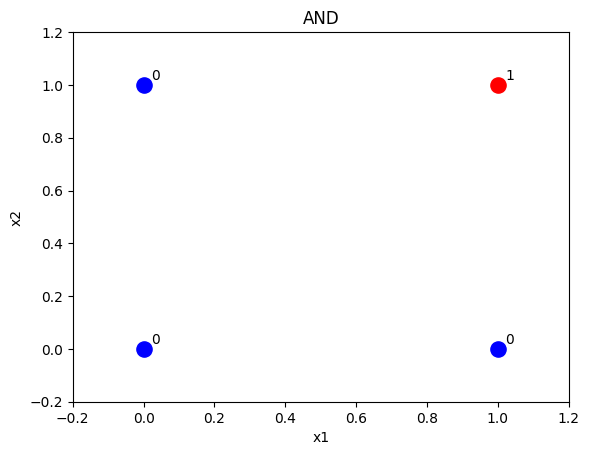

In [81]:
plot_points(y_and, "AND")

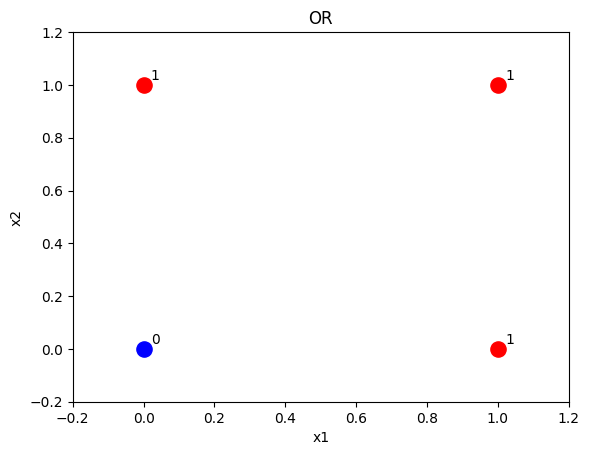

In [82]:
plot_points(y_or,  "OR")

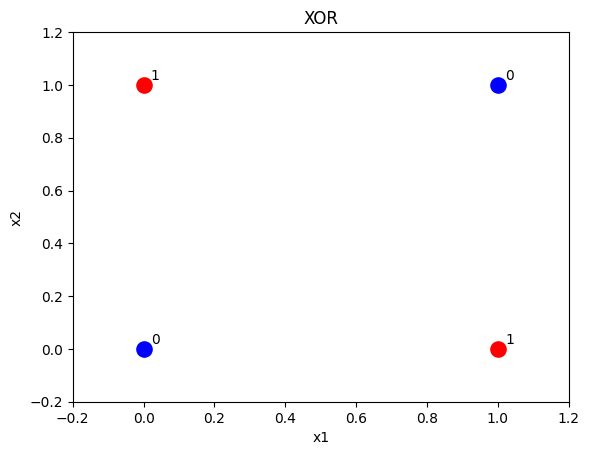

In [83]:
plot_points(y_xor, "XOR")